# Weak GPU Complexity Benchmark: Mat32 / top_q / N

目标是稳定识别经验复杂度、定位瓶颈、比较算法在弱 GPU 上的拐点，不追求单点最快。

本 notebook 只回答四个问题：

- Q1: `gpu_v1_topq0` 的总时间随 `N` 如何增长。
- Q2: `gpu_v3_topq` 相比 `gpu_v1_topq0` 在不同 `N` 下更快还是更慢，拐点在哪里。
- Q3: 时间增长主要来自哪一段：`precompute/eigenspace/solve/predict`。
- Q4: 随着 `N` 增大，`top_q>0` 的优势是在扩大还是缩小。

实验拆成三层：

1. 端到端时间 vs `N`
2. 分阶段时间 vs `N`
3. 迭代统计 vs `N`

控制变量固定：

- 数据分布固定（2D + Mat32 + 固定采样分布）
- `eps` 固定
- `cg_tol` 固定
- `N_test` 固定
- 每条曲线内部 `top_q` 固定

输出要求：

- 每次 run 结果会 `print`
- 同时保存 `raw csv`
- 聚合统计保存 `summary csv`
- 图像保存到 `png`


In [28]:
## For github import
import os
import sys

GITHUB_USER = "Yifiwifi"
REPO_NAME = "EFGP-Eigenpro"
SUB_DIR = "efgp_eigenpro_py"
PROJECT_PATH = f"/content/{REPO_NAME}"

if not os.path.exists(PROJECT_PATH):
    !git clone https://github.com/{GITHUB_USER}/{REPO_NAME}.git
else:
    %cd {PROJECT_PATH}
    !git pull origin main

CODE_ROOT = os.path.join(PROJECT_PATH, SUB_DIR)
if CODE_ROOT not in sys.path:
    sys.path.append(CODE_ROOT)

print("Checking runtime dependencies")
!pip install cufinufft cupy-cuda12x --extra-index-url https://pypi.nvidia.com

requirements_path = os.path.join(CODE_ROOT, "requirements.txt")
if os.path.exists(requirements_path):
    !pip install -r {requirements_path}

sanity_check_path = os.path.join(CODE_ROOT, "gpu/sanity_check")
if os.path.exists(sanity_check_path):
    os.chdir(sanity_check_path)
    print("cwd:", os.getcwd())
else:
    print("sanity_check path not found:", sanity_check_path)

# Refresh runtime library path for some Colab images
os.environ["LD_LIBRARY_PATH"] = "/usr/local/lib:" + os.environ.get("LD_LIBRARY_PATH", "")
!ldconfig /usr/local/lib

print("=" * 40)
try:
    import torch
    import cupy as cp
    import cufinufft
    cp.cuda.Stream.null.synchronize()
    print("PyTorch:", torch.__version__)
    print("GPU:", torch.cuda.get_device_name(0))
    print("cufinufft import ok")
except Exception as e:
    print("runtime check failed:", e)
print("=" * 40)


Checking runtime dependencies


fatal: destination path 'EFGP-Eigenpro' already exists and is not an empty directory.


Looking in indexes: https://mirrors.aliyun.com/pypi/simple, https://pypi.nvidia.com
sanity_check path not found: /content/EFGP-Eigenpro\efgp_eigenpro_py\gpu/sanity_check



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


PyTorch: 2.5.1+cu124
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
cufinufft import ok


'ldconfig' �����ڲ����ⲿ���Ҳ���ǿ����еĳ���
���������ļ���


In [29]:
import gc
import os
import sys
import time
import json
import traceback
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_here = Path.cwd().resolve()
_candidates = [
    _here,
    _here.parent,
    _here.parent.parent,
    _here.parent.parent.parent,
    Path("D:/NU/ML"),
]
for p in _candidates:
    pkg_dir = p / "efgp_eigenpro_py"
    if pkg_dir.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))
        break

from efgp_eigenpro_py.kernels import make_matern
from efgp_eigenpro_py.efgp_solver import EFGPSolver
from efgp_eigenpro_py.benchmark import make_dataset, make_test_set, true_func_2d, compute_rmse
from efgp_eigenpro_py.gpu.backends import BackendConfig
from efgp_eigenpro_py.gpu.versions import GPURunConfig, run_v1_pure_efgp, run_v3_full_gpu_eigenspace
from efgp_eigenpro_py.gpu.v3_eigenspace import EigenspaceConfig

try:
    import cupy as cp
except Exception:
    cp = None

np.set_printoptions(precision=6, suppress=True)
print("cwd:", os.getcwd())
print("sys.path[0]:", sys.path[0])
print("cupy available:", cp is not None)


cwd: d:\NU\ML\efgp_eigenpro_py\gpu\sanity_check
sys.path[0]: D:\NU\ML
cupy available: True


In [30]:
# ---- Fixed controls ----
DIM = 2
LENGTHSCALE = 0.1
NU = 1.5
REG_LAMBDA = 0.1
EPS = 1e-5
SOLVE_TOL = 1e-6
GPU_MAXITER = 3000
GPU_NUFFT = "auto"
L2_SCALED = True

N_TEST = 1000
NOISE = 0.02
SEED_TRAIN_BASE = 20260421
SEED_TEST = 1

# Recommended weak-GPU first round
N_LIST = [100_000, 300_000]                    # [100_000, 300_000, 1_000_000, 3_000_000, 10_000_000]
MODE_SPECS = [
    {"mode": "gpu_v1_topq0", "top_q": 0},
    {"mode": "gpu_v3_topq", "top_q": 32},
    {"mode": "gpu_v3_topq", "top_q": 64},
]

REPEATS_POLICY = {
    "small": 20,   # N <= 1e6
    "mid": 10,     # N == 3e6
    "large": 5,    # N >= 1e7
}

WARMUP_N = 100_000
WARMUP_SEED = 7
CLEAR_POOL_PER_N = True

V3_OVERSAMPLE = 16
V3_N_ITER = 3

RUN_TAG = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = Path("outputs") / f"weak_gpu_complexity_{RUN_TAG}"
OUT_DIR.mkdir(parents=True, exist_ok=True)
RAW_CSV = OUT_DIR / "raw_runs.csv"
SUMMARY_CSV = OUT_DIR / "summary_by_mode_n.csv"
ENV_JSON = OUT_DIR / "env_info.json"

print("RUN_TAG:", RUN_TAG)
print("OUT_DIR:", OUT_DIR)
print("N_LIST:", N_LIST)
print("MODE_SPECS:", MODE_SPECS)


RUN_TAG: 20260423_003358
OUT_DIR: outputs\weak_gpu_complexity_20260423_003358
N_LIST: [100000, 300000]
MODE_SPECS: [{'mode': 'gpu_v1_topq0', 'top_q': 0}, {'mode': 'gpu_v3_topq', 'top_q': 32}, {'mode': 'gpu_v3_topq', 'top_q': 64}]


In [31]:
kernel = make_matern(lengthscale=LENGTHSCALE, nu=NU, dim=DIM, variance=1.0)
x_test, y_test = make_test_set(DIM, N_TEST, true_func_2d, seed=SEED_TEST)


def _sync_gpu():
    if cp is not None:
        cp.cuda.Stream.null.synchronize()


def _clear_state(clear_pool=False):
    _sync_gpu()
    gc.collect()
    if cp is not None and clear_pool:
        cp.get_default_memory_pool().free_all_blocks()
        cp.get_default_pinned_memory_pool().free_all_blocks()
    _sync_gpu()


def _gpu_mem_used_gb():
    if cp is None:
        return np.nan
    try:
        free_b, total_b = cp.cuda.runtime.memGetInfo()
        return float((total_b - free_b) / (1024 ** 3))
    except Exception:
        return np.nan


def _device_name():
    if cp is None:
        return "cpu"
    try:
        return cp.cuda.runtime.getDeviceProperties(0)["name"].decode("utf-8")
    except Exception:
        return "unknown_gpu"


def _pick_repeats(n_train: int) -> int:
    if n_train <= 1_000_000:
        return int(REPEATS_POLICY["small"])
    if n_train >= 10_000_000:
        return int(REPEATS_POLICY["large"])
    return int(REPEATS_POLICY["mid"])


def _collect_env_info():
    info = {
        "timestamp": datetime.now().isoformat(),
        "python": sys.version,
        "platform": sys.platform,
        "device_name": _device_name(),
        "eps": EPS,
        "solve_tol": SOLVE_TOL,
        "gpu_maxiter": GPU_MAXITER,
        "nufft_mode": GPU_NUFFT,
        "l2_scaled": L2_SCALED,
        "dim": DIM,
        "kernel": "Mat32",
        "nu": NU,
        "lengthscale": LENGTHSCALE,
        "reg_lambda": REG_LAMBDA,
        "n_test": N_TEST,
        "n_list": [int(v) for v in N_LIST],
        "mode_specs": MODE_SPECS,
    }
    try:
        import cupy
        info["cupy"] = cupy.__version__
    except Exception:
        info["cupy"] = "unavailable"
    try:
        import cufinufft
        info["cufinufft"] = getattr(cufinufft, "__version__", "unknown")
    except Exception:
        info["cufinufft"] = "unavailable"
    return info


def _extract_common_metrics(diag: dict):
    return {
        "cg_iters": int(diag.get("cg_iters", -1)),
        "cg_relres": float(diag.get("cg_relres", np.nan)),
        "n_matvec": int(diag.get("n_matvec", 0)),
        "t_matvec_total": float(diag.get("t_matvec_total", np.nan)),
        "n_precond": int(diag.get("n_precond", 0)),
        "t_precond_total": float(diag.get("t_precond_total", np.nan)),
        "time_precompute": float(diag.get("time_precompute", np.nan)),
        "time_eigenspace": float(diag.get("time_eigenspace", 0.0)),
        "time_precond_build": float(diag.get("time_precond_build", 0.0)),
        "time_solve": float(diag.get("time_solve", np.nan)),
        "time_predict": float(diag.get("time_predict", np.nan)),
        "nufft_stage": str(diag.get("nufft_stage", "")),
        "device_name": str(diag.get("device_name", "")),
    }


def _run_case_once(mode: str, top_q: int, n_train: int, seed_train: int, warmup_only=False) -> dict:
    x_train, y_train = make_dataset(DIM, n_train, true_func_2d, noise=NOISE, seed=seed_train)

    solver = EFGPSolver(
        kernel=kernel,
        reg_lambda=REG_LAMBDA,
        eps=EPS,
        nufft_tol=1e-10,
        l2scaled=L2_SCALED,
    )
    cfg = GPURunConfig(
        reg_lambda=REG_LAMBDA,
        tol=SOLVE_TOL,
        maxiter=GPU_MAXITER,
        chunk_size=None,
        debug_finite_checks=False,
        backend=BackendConfig(nufft=GPU_NUFFT),
    )

    _sync_gpu()
    mem_before = _gpu_mem_used_gb()
    t0 = time.perf_counter()
    if mode == "gpu_v1_topq0":
        out = run_v1_pure_efgp(solver, x_train, y_train, cfg)
    elif mode == "gpu_v3_topq":
        if int(top_q) <= 0:
            raise ValueError("top_q must be > 0 for gpu_v3_topq")
        eig_cfg = EigenspaceConfig(
            q_max=int(top_q),
            block_size=int(top_q + V3_OVERSAMPLE),
            n_iter=int(V3_N_ITER),
        )
        out = run_v3_full_gpu_eigenspace(solver, x_train, y_train, cfg, eig_cfg)
    else:
        raise ValueError(f"unsupported mode: {mode}")
    _sync_gpu()
    t1 = time.perf_counter()
    mem_after = _gpu_mem_used_gb()

    if warmup_only:
        return {"status": "warmup_done"}

    state_cpu = solver.precompute(x_train, y_train)
    if cp is None:
        beta_cpu = np.asarray(out.beta_gpu)
    else:
        beta_cpu = cp.asnumpy(out.beta_gpu)
    yhat = solver.predict(x_test, beta_cpu, state_cpu)
    rmse = float(compute_rmse(yhat, y_test))

    diag = out.diagnostics
    row = {
        "run_id": f"{RUN_TAG}_{mode}_q{int(top_q)}_N{int(n_train)}_{seed_train}",
        "timestamp": datetime.now().isoformat(),
        "mode": mode,
        "N": int(n_train),
        "eps": float(EPS),
        "top_q": int(top_q),
        "reg_lambda": float(REG_LAMBDA),
        "cg_tol": float(SOLVE_TOL),
        "wall_s_total": float(t1 - t0),
        "rmse_test": float(rmse),
        "peak_mem_gb": float(np.nanmax([mem_before, mem_after])),
        "status": "ok",
        "error": "",
    }
    row.update(_extract_common_metrics(diag))
    return row


def _run_warmup_for_mode(mode: str, top_q: int, n_ref: int):
    n_warm = int(min(n_ref, WARMUP_N))
    print(f"warmup start: mode={mode}, top_q={top_q}, N={n_warm}")
    _clear_state(clear_pool=False)
    _ = _run_case_once(mode=mode, top_q=top_q, n_train=n_warm, seed_train=WARMUP_SEED, warmup_only=True)
    _clear_state(clear_pool=False)
    print(f"warmup done: mode={mode}, top_q={top_q}")


env_info = _collect_env_info()
ENV_JSON.write_text(json.dumps(env_info, indent=2), encoding="utf-8")
print("env info saved:", ENV_JSON)
print(json.dumps(env_info, indent=2))


env info saved: outputs\weak_gpu_complexity_20260423_003358\env_info.json
{
  "timestamp": "2026-04-23T00:33:58.230861",
  "python": "3.12.3 | packaged by conda-forge | (main, Apr 15 2024, 18:20:11) [MSC v.1938 64 bit (AMD64)]",
  "platform": "win32",
  "device_name": "NVIDIA GeForce RTX 3050 Laptop GPU",
  "eps": 1e-05,
  "solve_tol": 1e-06,
  "gpu_maxiter": 3000,
  "nufft_mode": "auto",
  "l2_scaled": true,
  "dim": 2,
  "kernel": "Mat32",
  "nu": 1.5,
  "lengthscale": 0.1,
  "reg_lambda": 0.1,
  "n_test": 1000,
  "n_list": [
    100000,
    300000
  ],
  "mode_specs": [
    {
      "mode": "gpu_v1_topq0",
      "top_q": 0
    },
    {
      "mode": "gpu_v3_topq",
      "top_q": 32
    },
    {
      "mode": "gpu_v3_topq",
      "top_q": 64
    }
  ],
  "cupy": "13.3.0",
  "cufinufft": "2.5.1"
}


In [32]:
# --- Add combo experiments (from v1 COMBO_GRID_VALUES) ---
from types import SimpleNamespace

from efgp_eigenpro_py.discretization import GridSpec
from efgp_eigenpro_py.gpu import surrogate_ops as sur_ops
from efgp_eigenpro_py.gpu.backends import build_gpu_backend_bundle
from efgp_eigenpro_py.gpu.contexts import ensure_gpu_data_context, GPUOperatorContext
from efgp_eigenpro_py.gpu.v1_ops import apply_A_v1, predict_v1
from efgp_eigenpro_py.gpu.v2_preconditioner import GPUPreconditionerData, apply_preconditioner_v2
from efgp_eigenpro_py.gpu.iterative_solvers import pcg_solve_gpu

COMBO_CFG_V1 = {
    "name": "combo_g0p1_e100_s0p3",
    "kind": "combo",
    "grid_scale": 0.1,
    "grid_m": None,
    "eps_factor": 100.0,
    "subsample_frac": 0.3,
    "subsample_seed": 0,
    "sur_iter": 1,
    "refine_iter": 1,
    "oversample": V3_OVERSAMPLE,
    "block_size": None,
}

_combo_specs = [
    {"mode": "gpu_v3_topq_combo", "top_q": 32, "combo_cfg": COMBO_CFG_V1},
    {"mode": "gpu_v3_topq_combo", "top_q": 64, "combo_cfg": COMBO_CFG_V1},
]
_existing = {(str(s.get("mode", "")), int(s.get("top_q", -1))) for s in MODE_SPECS}
for spec in _combo_specs:
    k = (spec["mode"], int(spec["top_q"]))
    if k not in _existing:
        MODE_SPECS.append(spec)


def _build_surrogate_grid(fine_m: int, fine_h: float, grid_scale=None, grid_m=None) -> GridSpec:
    if grid_m is not None:
        m_coarse = int(grid_m)
    else:
        scale = 1.0 if grid_scale is None else float(grid_scale)
        m_coarse = max(1, int(fine_m * scale))
    xis = np.arange(-m_coarse, m_coarse + 1) * float(fine_h)
    return GridSpec(xis=xis, h=float(fine_h), mtot=xis.size, hm=m_coarse)


def _embed_coarse_to_fine(xp, vecs_coarse, coarse_m: int, fine_m: int, dim: int = 2):
    if coarse_m == fine_m:
        return xp.asarray(vecs_coarse)
    cols = []
    for j in range(vecs_coarse.shape[1]):
        v = xp.asarray(vecs_coarse[:, j]).reshape((2 * coarse_m + 1,) * dim)
        vf = xp.zeros((2 * fine_m + 1,) * dim, dtype=v.dtype)
        s = fine_m - coarse_m
        e = s + (2 * coarse_m + 1)
        if dim == 2:
            vf[s:e, s:e] = v
        else:
            vf[(slice(s, e),) * dim] = v
        cols.append(vf.reshape(-1))
    return xp.stack(cols, axis=1)


def _run_v3_combo_case(solver, cfg, x_train, y_train, top_q: int, combo_cfg: dict):
    backend = build_gpu_backend_bundle(cfg.backend)
    xp = backend.xp
    q_max = int(top_q)

    data_ctx = ensure_gpu_data_context(backend, x_train, y_train, state=None)
    data_ctx.meta["debug_finite_checks"] = bool(cfg.debug_finite_checks)
    op_ctx = GPUOperatorContext()

    t0 = time.perf_counter()
    data_ctx = sur_ops.gpu_precompute_v1(
        backend,
        solver.kernel,
        solver.eps,
        solver.nufft_tol,
        data_ctx,
        op_ctx,
        l2scaled=solver.l2scaled,
        chunk_size=cfg.chunk_size,
    )
    t1 = time.perf_counter()

    def _apply_block(local_ctx, local_op_ctx):
        def _fn(V):
            V = xp.asarray(V, dtype=xp.complex128)
            if V.ndim == 1:
                V = V.reshape(-1, 1)
            out = xp.empty_like(V)
            for i in range(V.shape[1]):
                apply_A_v1(
                    backend,
                    local_ctx,
                    V[:, i],
                    float(cfg.reg_lambda),
                    local_op_ctx,
                    out=out[:, i],
                )
            return out
        return _fn

    apply_A_fine = _apply_block(data_ctx, op_ctx)

    fine_mtot = int(data_ctx.meta.get("mtot", 0))
    fine_m = max(1, (fine_mtot - 1) // 2)
    fine_h = float(data_ctx.meta.get("h", 1.0))

    frac = float(combo_cfg.get("subsample_frac", 1.0))
    frac = min(max(frac, 1e-6), 1.0)
    n_sub = max(q_max + 2, int(len(x_train) * frac))
    n_sub = min(n_sub, len(x_train))
    seed = int(combo_cfg.get("subsample_seed", 0))
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(x_train), size=n_sub, replace=False)
    x_use = np.asarray(x_train[idx])
    y_use = np.asarray(y_train[idx])

    eps_factor = float(combo_cfg.get("eps_factor", 1.0))
    eps_sur = float(solver.eps) * eps_factor

    grid_override = _build_surrogate_grid(
        fine_m,
        fine_h,
        grid_scale=combo_cfg.get("grid_scale", 1.0),
        grid_m=combo_cfg.get("grid_m", None),
    )

    data_ctx_sur = ensure_gpu_data_context(backend, x_use, y_use, state=None)
    data_ctx_sur.meta["debug_finite_checks"] = bool(cfg.debug_finite_checks)
    op_ctx_sur = GPUOperatorContext()

    t_sur_pre0 = time.perf_counter()
    data_ctx_sur = sur_ops.gpu_precompute_v1(
        backend,
        solver.kernel,
        eps_sur,
        solver.nufft_tol,
        data_ctx_sur,
        op_ctx_sur,
        l2scaled=solver.l2scaled,
        chunk_size=cfg.chunk_size,
        grid_override=grid_override,
    )
    t_sur_pre1 = time.perf_counter()

    size_sur = int(data_ctx_sur.rhs_gpu.size)
    if size_sur <= q_max:
        raise ValueError(f"surrogate size ({size_sur}) must be > top_q ({q_max})")

    sur_oversample = int(combo_cfg.get("oversample", V3_OVERSAMPLE))
    sur_block = combo_cfg.get("block_size")
    sur_block = int(q_max + sur_oversample) if sur_block is None else int(sur_block)
    sur_block = min(sur_block, size_sur)
    if sur_block <= q_max:
        sur_block = q_max + 1

    apply_A_sur = _apply_block(data_ctx_sur, op_ctx_sur)
    eig_cfg_sur = sur_ops.EigenspaceConfig(
        q_max=q_max,
        block_size=sur_block,
        n_iter=int(combo_cfg.get("sur_iter", 1)),
    )
    vals_sur, vecs_sur, _ = sur_ops.estimate_top_eigenspace_v3(
        backend=backend,
        apply_A_block_gpu=apply_A_sur,
        size=size_sur,
        cfg=eig_cfg_sur,
    )

    init_Q = vecs_sur
    init_Q = _embed_coarse_to_fine(xp, vecs_sur, int(grid_override.hm), fine_m, dim=DIM)

    eig_cfg_fine = sur_ops.EigenspaceConfig(
        q_max=q_max,
        block_size=max(sur_block, q_max + 1),
        n_iter=int(combo_cfg.get("refine_iter", 1)),
    )

    vals_gpu, vecs_gpu, eig_diag = sur_ops.estimate_top_eigenspace_v3(
        backend=backend,
        apply_A_block_gpu=apply_A_fine,
        size=int(data_ctx.rhs_gpu.size),
        cfg=eig_cfg_fine,
        init_Q=init_Q,
    )
    t2 = time.perf_counter()

    if vals_gpu.size <= q_max:
        mu = float(vals_gpu[-1])
    else:
        mu = float(vals_gpu[q_max])
    scale_gpu = xp.asarray(1.0 - (mu / vals_gpu[:q_max]))
    precond_data = GPUPreconditionerData(
        U_gpu=vecs_gpu[:, :q_max],
        UH_gpu=vecs_gpu[:, :q_max].conj().T,
        scale_gpu=scale_gpu,
        scale_col_gpu=scale_gpu.reshape(-1, 1),
    )
    t3 = time.perf_counter()

    def _matvec(v, out):
        apply_A_v1(backend, data_ctx, v, float(cfg.reg_lambda), op_ctx, out=out)

    def _precond(v, out):
        apply_preconditioner_v2(backend, precond_data, v, op_ctx=op_ctx, out=out)

    beta_gpu, it, relres, stats = pcg_solve_gpu(
        backend,
        _matvec,
        _precond,
        data_ctx.rhs_gpu,
        op_ctx,
        cfg.tol,
        cfg.maxiter,
        return_stats=True,
    )
    t4 = time.perf_counter()

    if cp is not None:
        cp.cuda.Stream.null.synchronize()
    tp0 = time.perf_counter()
    _ = predict_v1(backend, data_ctx, x_test, beta_gpu)
    if cp is not None:
        cp.cuda.Stream.null.synchronize()
    tp1 = time.perf_counter()

    diag = {
        "cg_iters": int(it),
        "cg_relres": float(relres),
        "n_matvec": int(stats.get("n_matvec", 0)),
        "t_matvec_total": float(stats.get("t_matvec_total", np.nan)),
        "n_precond": int(stats.get("n_precond", 0)),
        "t_precond_total": float(stats.get("t_precond_total", np.nan)),
        "time_precompute": float(t1 - t0),
        "time_eigenspace": float(t2 - t1),
        "time_precond_build": float(t3 - t2),
        "time_solve": float(t4 - t3),
        "time_predict": float(tp1 - tp0),
        "nufft_stage": str(data_ctx.meta.get("nufft_stage", "")),
        "device_name": str(backend.device_name),
        "surrogate_precompute": float(t_sur_pre1 - t_sur_pre0),
        "surrogate_tag": str(combo_cfg.get("name", "combo")),
    }
    return SimpleNamespace(beta_gpu=beta_gpu, diagnostics=diag)


def _run_case_once(mode: str, top_q: int, n_train: int, seed_train: int, warmup_only=False) -> dict:
    x_train, y_train = make_dataset(DIM, n_train, true_func_2d, noise=NOISE, seed=seed_train)

    solver = EFGPSolver(
        kernel=kernel,
        reg_lambda=REG_LAMBDA,
        eps=EPS,
        nufft_tol=1e-10,
        l2scaled=L2_SCALED,
    )
    cfg = GPURunConfig(
        reg_lambda=REG_LAMBDA,
        tol=SOLVE_TOL,
        maxiter=GPU_MAXITER,
        chunk_size=None,
        debug_finite_checks=False,
        backend=BackendConfig(nufft=GPU_NUFFT),
    )

    _sync_gpu()
    mem_before = _gpu_mem_used_gb()
    t0 = time.perf_counter()
    if mode == "gpu_v1_topq0":
        out = run_v1_pure_efgp(solver, x_train, y_train, cfg)
    elif mode == "gpu_v3_topq":
        if int(top_q) <= 0:
            raise ValueError("top_q must be > 0 for gpu_v3_topq")
        eig_cfg = EigenspaceConfig(
            q_max=int(top_q),
            block_size=int(top_q + V3_OVERSAMPLE),
            n_iter=int(V3_N_ITER),
        )
        out = run_v3_full_gpu_eigenspace(solver, x_train, y_train, cfg, eig_cfg)
    elif mode == "gpu_v3_topq_combo":
        if int(top_q) <= 0:
            raise ValueError("top_q must be > 0 for gpu_v3_topq_combo")
        out = _run_v3_combo_case(solver, cfg, x_train, y_train, int(top_q), COMBO_CFG_V1)
    else:
        raise ValueError(f"unsupported mode: {mode}")
    _sync_gpu()
    t1 = time.perf_counter()
    mem_after = _gpu_mem_used_gb()

    if warmup_only:
        return {"status": "warmup_done"}

    state_cpu = solver.precompute(x_train, y_train)
    if cp is None:
        beta_cpu = np.asarray(out.beta_gpu)
    else:
        beta_cpu = cp.asnumpy(out.beta_gpu)
    yhat = solver.predict(x_test, beta_cpu, state_cpu)
    rmse = float(compute_rmse(yhat, y_test))

    diag = out.diagnostics
    row = {
        "run_id": f"{RUN_TAG}_{mode}_q{int(top_q)}_N{int(n_train)}_{seed_train}",
        "timestamp": datetime.now().isoformat(),
        "mode": mode,
        "N": int(n_train),
        "eps": float(EPS),
        "top_q": int(top_q),
        "reg_lambda": float(REG_LAMBDA),
        "cg_tol": float(SOLVE_TOL),
        "wall_s_total": float(t1 - t0),
        "rmse_test": float(rmse),
        "peak_mem_gb": float(np.nanmax([mem_before, mem_after])),
        "status": "ok",
        "error": "",
    }
    row.update(_extract_common_metrics(diag))
    row["surrogate_tag"] = str(diag.get("surrogate_tag", ""))
    return row


# refresh env info so mode_specs includes combo experiments
env_info = _collect_env_info()
ENV_JSON.write_text(json.dumps(env_info, indent=2), encoding="utf-8")
print("MODE_SPECS (extended):", MODE_SPECS)
print("env info refreshed:", ENV_JSON)

MODE_SPECS (extended): [{'mode': 'gpu_v1_topq0', 'top_q': 0}, {'mode': 'gpu_v3_topq', 'top_q': 32}, {'mode': 'gpu_v3_topq', 'top_q': 64}, {'mode': 'gpu_v3_topq_combo', 'top_q': 32, 'combo_cfg': {'name': 'combo_g0p1_e100_s0p3', 'kind': 'combo', 'grid_scale': 0.1, 'grid_m': None, 'eps_factor': 100.0, 'subsample_frac': 0.3, 'subsample_seed': 0, 'sur_iter': 1, 'refine_iter': 1, 'oversample': 16, 'block_size': None}}, {'mode': 'gpu_v3_topq_combo', 'top_q': 64, 'combo_cfg': {'name': 'combo_g0p1_e100_s0p3', 'kind': 'combo', 'grid_scale': 0.1, 'grid_m': None, 'eps_factor': 100.0, 'subsample_frac': 0.3, 'subsample_seed': 0, 'sur_iter': 1, 'refine_iter': 1, 'oversample': 16, 'block_size': None}}]
env info refreshed: outputs\weak_gpu_complexity_20260423_003358\env_info.json


In [33]:
rows = []

for spec in MODE_SPECS:
    _run_warmup_for_mode(spec["mode"], int(spec["top_q"]), n_ref=int(N_LIST[0]))

for n_train in N_LIST:
    print("=" * 80)
    print(f"N={n_train} start")

    if CLEAR_POOL_PER_N:
        _clear_state(clear_pool=True)

    for spec in MODE_SPECS:
        mode = str(spec["mode"])
        top_q = int(spec["top_q"])
        repeats = _pick_repeats(int(n_train))

        print("-" * 80)
        print(f"mode={mode}, top_q={top_q}, repeats={repeats}")

        for rep in range(repeats):
            seed_train = int(SEED_TRAIN_BASE + rep)
            try:
                _clear_state(clear_pool=False)
                row = _run_case_once(
                    mode=mode,
                    top_q=top_q,
                    n_train=int(n_train),
                    seed_train=seed_train,
                    warmup_only=False,
                )
                row["repeat_idx"] = int(rep)
                row["repeat_count"] = int(repeats)
                rows.append(row)

                print(
                    f"ok rep={rep:02d} N={n_train} mode={mode} q={top_q} "
                    f"wall={row['wall_s_total']:.4f}s solve={row['time_solve']:.4f}s "
                    f"iter={row['cg_iters']} rmse={row['rmse_test']:.6e}"
                )
            except Exception as e:
                tb = traceback.format_exc()
                err_row = {
                    "run_id": f"{RUN_TAG}_{mode}_q{top_q}_N{n_train}_rep{rep}",
                    "timestamp": datetime.now().isoformat(),
                    "mode": mode,
                    "N": int(n_train),
                    "eps": float(EPS),
                    "top_q": int(top_q),
                    "reg_lambda": float(REG_LAMBDA),
                    "cg_tol": float(SOLVE_TOL),
                    "repeat_idx": int(rep),
                    "repeat_count": int(repeats),
                    "wall_s_total": np.nan,
                    "time_precompute": np.nan,
                    "time_eigenspace": np.nan,
                    "time_precond_build": np.nan,
                    "time_solve": np.nan,
                    "time_predict": np.nan,
                    "cg_iters": np.nan,
                    "cg_relres": np.nan,
                    "n_matvec": np.nan,
                    "t_matvec_total": np.nan,
                    "n_precond": np.nan,
                    "t_precond_total": np.nan,
                    "rmse_test": np.nan,
                    "peak_mem_gb": np.nan,
                    "nufft_stage": "",
                    "device_name": _device_name(),
                    "status": "error",
                    "error": f"{type(e).__name__}: {e}",
                    "error_traceback": tb,
                }
                rows.append(err_row)
                print(f"error rep={rep:02d} N={n_train} mode={mode} q={top_q}: {type(e).__name__}: {e}")

        df_partial = pd.DataFrame(rows)
        df_partial.to_csv(RAW_CSV, index=False)
        print("partial raw csv saved:", RAW_CSV, "rows=", len(df_partial))

raw_df = pd.DataFrame(rows)
raw_df.to_csv(RAW_CSV, index=False)
print("final raw csv:", RAW_CSV)
print("raw rows:", len(raw_df))

with pd.option_context("display.max_rows", 200, "display.max_columns", 200):
    display(raw_df.tail(min(len(raw_df), 20)))


warmup start: mode=gpu_v1_topq0, top_q=0, N=100000
warmup done: mode=gpu_v1_topq0, top_q=0
warmup start: mode=gpu_v3_topq, top_q=32, N=100000
warmup done: mode=gpu_v3_topq, top_q=32
warmup start: mode=gpu_v3_topq, top_q=64, N=100000
warmup done: mode=gpu_v3_topq, top_q=64
warmup start: mode=gpu_v3_topq_combo, top_q=32, N=100000
warmup done: mode=gpu_v3_topq_combo, top_q=32
warmup start: mode=gpu_v3_topq_combo, top_q=64, N=100000
warmup done: mode=gpu_v3_topq_combo, top_q=64
N=100000 start
--------------------------------------------------------------------------------
mode=gpu_v1_topq0, top_q=0, repeats=20
ok rep=00 N=100000 mode=gpu_v1_topq0 q=0 wall=0.9108s solve=0.8835s iter=400 rmse=2.597204e-03
ok rep=01 N=100000 mode=gpu_v1_topq0 q=0 wall=0.9691s solve=0.9443s iter=398 rmse=2.700456e-03
ok rep=02 N=100000 mode=gpu_v1_topq0 q=0 wall=0.9717s solve=0.9477s iter=414 rmse=2.518334e-03
ok rep=03 N=100000 mode=gpu_v1_topq0 q=0 wall=0.9503s solve=0.9258s iter=407 rmse=2.613203e-03
ok rep

,run_id,timestamp,mode,N,eps,top_q,reg_lambda,cg_tol,wall_s_total,rmse_test,peak_mem_gb,status,error,cg_iters,cg_relres,n_matvec,t_matvec_total,n_precond,t_precond_total,time_precompute,time_eigenspace,time_precond_build,time_solve,time_predict,nufft_stage,device_name,surrogate_tag,repeat_idx,repeat_count
180,20260423_003358_gpu_v3_topq_combo_q64_N300000_...,2026-04-23T00:39:18.480430,gpu_v3_topq_combo,300000,0.00001,64,0.1,0.000001,1.484395,0.001813,1.488379,ok,,196,9.835201e-07,197,0.288254,196,0.178287,0.035825,0.772837,0.000247,0.670611,0.003615,cufinufft,NVIDIA GeForce RTX 3050 Laptop GPU,combo_g0p1_e100_s0p3,0,20
181,20260423_003358_gpu_v3_topq_combo_q64_N300000_...,2026-04-23T00:39:20.445683,gpu_v3_topq_combo,300000,0.00001,64,0.1,0.000001,1.570730,0.001873,1.488379,ok,,200,9.566241e-07,201,0.316193,200,0.191628,0.035011,0.775653,0.000356,0.751994,0.005710,cufinufft,NVIDIA GeForce RTX 3050 Laptop GPU,combo_g0p1_e100_s0p3,1,20
182,20260423_003358_gpu_v3_topq_combo_q64_N300000_...,2026-04-23T00:39:22.407106,gpu_v3_topq_combo,300000,0.00001,64,0.1,0.000001,1.551345,0.001846,1.488379,ok,,203,9.495101e-07,204,0.303910,203,0.187994,0.036860,0.800432,0.000258,0.708280,0.003587,cufinufft,NVIDIA GeForce RTX 3050 Laptop GPU,combo_g0p1_e100_s0p3,2,20
183,20260423_003358_gpu_v3_topq_combo_q64_N300000_...,2026-04-23T00:39:24.282734,gpu_v3_topq_combo,300000,0.00001,64,0.1,0.000001,1.538008,0.001770,1.488379,ok,,204,9.158043e-07,205,0.307052,204,0.189346,0.034407,0.768753,0.000259,0.729185,0.003546,cufinufft,NVIDIA GeForce RTX 3050 Laptop GPU,combo_g0p1_e100_s0p3,3,20
184,20260423_003358_gpu_v3_topq_combo_q64_N300000_...,2026-04-23T00:39:26.189770,gpu_v3_topq_combo,300000,0.00001,64,0.1,0.000001,1.561297,0.001906,1.488379,ok,,200,8.838320e-07,201,0.307312,200,0.187882,0.037267,0.804003,0.000278,0.714340,0.003859,cufinufft,NVIDIA GeForce RTX 3050 Laptop GPU,combo_g0p1_e100_s0p3,4,20
185,20260423_003358_gpu_v3_topq_combo_q64_N300000_...,2026-04-23T00:39:28.086890,gpu_v3_topq_combo,300000,0.00001,64,0.1,0.000001,1.559348,0.001738,1.488379,ok,,206,7.366441e-07,207,0.307590,206,0.190576,0.037525,0.801092,0.000249,0.715046,0.004128,cufinufft,NVIDIA GeForce RTX 3050 Laptop GPU,combo_g0p1_e100_s0p3,5,20
186,20260423_003358_gpu_v3_topq_combo_q64_N300000_...,2026-04-23T00:39:29.967814,gpu_v3_topq_combo,300000,0.00001,64,0.1,0.000001,1.539502,0.001884,1.488379,ok,,204,9.678319e-07,205,0.303266,204,0.187243,0.035455,0.787202,0.000263,0.711061,0.004015,cufinufft,NVIDIA GeForce RTX 3050 Laptop GPU,combo_g0p1_e100_s0p3,6,20
187,20260423_003358_gpu_v3_topq_combo_q64_N300000_...,2026-04-23T00:39:31.874264,gpu_v3_topq_combo,300000,0.00001,64,0.1,0.000001,1.552231,0.001720,1.488379,ok,,206,7.808077e-07,207,0.307441,206,0.189333,0.035266,0.790188,0.000249,0.721124,0.004007,cufinufft,NVIDIA GeForce RTX 3050 Laptop GPU,combo_g0p1_e100_s0p3,7,20
188,20260423_003358_gpu_v3_topq_combo_q64_N300000_...,2026-04-23T00:39:33.799302,gpu_v3_topq_combo,300000,0.00001,64,0.1,0.000001,1.584388,0.001797,1.488379,ok,,200,9.984131e-07,201,0.308697,200,0.192477,0.036142,0.820675,0.000263,0.721954,0.003646,cufinufft,NVIDIA GeForce RTX 3050 Laptop GPU,combo_g0p1_e100_s0p3,8,20
189,20260423_003358_gpu_v3_topq_combo_q64_N300000_...,2026-04-23T00:39:35.711801,gpu_v3_topq_combo,300000,0.00001,64,0.1,0.000001,1.579897,0.001792,1.488379,ok,,206,7.748321e-07,207,0.316364,206,0.192608,0.036578,0.802693,0.000390,0.734771,0.003706,cufinufft,NVIDIA GeForce RTX 3050 Laptop GPU,combo_g0p1_e100_s0p3,9,20


In [34]:
ok_df = raw_df[raw_df["status"] == "ok"].copy()

if ok_df.empty:
    raise RuntimeError("no successful runs, cannot aggregate")

metrics = [
    "wall_s_total",
    "time_precompute",
    "time_eigenspace",
    "time_precond_build",
    "time_solve",
    "time_predict",
    "cg_iters",
    "t_matvec_total",
    "t_precond_total",
    "rmse_test",
    "peak_mem_gb",
]


def _quantile(x, q):
    s = pd.to_numeric(x, errors="coerce")
    if s.notna().sum() == 0:
        return np.nan
    return float(s.quantile(q))


group_cols = ["mode", "top_q", "N", "eps"]
gb = ok_df.groupby(group_cols, dropna=False)

parts = []
for m in metrics:
    part = gb[m].agg(["median", "mean", "std"]).reset_index()
    part = part.rename(columns={
        "median": f"{m}_median",
        "mean": f"{m}_mean",
        "std": f"{m}_std",
    })

    q10 = gb[m].apply(lambda s: _quantile(s, 0.10)).reset_index(name=f"{m}_p10")
    q90 = gb[m].apply(lambda s: _quantile(s, 0.90)).reset_index(name=f"{m}_p90")

    part = part.merge(q10, on=group_cols, how="left")
    part = part.merge(q90, on=group_cols, how="left")
    parts.append(part)

summary_df = parts[0]
for p in parts[1:]:
    keep_cols = [c for c in p.columns if c not in group_cols]
    summary_df = summary_df.merge(p[group_cols + keep_cols], on=group_cols, how="left")

count_df = raw_df.groupby(["mode", "top_q", "N", "eps"], as_index=False).agg(
    repeat_count=("run_id", "count"),
    fail_count=("status", lambda x: int((x != "ok").sum())),
)
summary_df = summary_df.merge(count_df, on=["mode", "top_q", "N", "eps"], how="left")

summary_df = summary_df.sort_values(["mode", "top_q", "N"]).reset_index(drop=True)
summary_df.to_csv(SUMMARY_CSV, index=False)

print("summary csv:", SUMMARY_CSV)
print("summary rows:", len(summary_df))

# local slopes on median wall time
summary_df["logN"] = np.log(summary_df["N"].astype(float))
summary_df["logT"] = np.log(summary_df["wall_s_total_median"].astype(float))
summary_df["local_alpha"] = np.nan

for (mode, top_q), idx in summary_df.groupby(["mode", "top_q"]).groups.items():
    ids = list(idx)
    for i in range(len(ids) - 1):
        i0, i1 = ids[i], ids[i + 1]
        dlogn = summary_df.loc[i1, "logN"] - summary_df.loc[i0, "logN"]
        dlogt = summary_df.loc[i1, "logT"] - summary_df.loc[i0, "logT"]
        summary_df.loc[i1, "local_alpha"] = float(dlogt / dlogn) if dlogn != 0 else np.nan

summary_df.to_csv(SUMMARY_CSV, index=False)

main_cols = [
    "mode", "top_q", "N", "eps",
    "wall_s_total_median", "wall_s_total_p10", "wall_s_total_p90",
    "time_precompute_median", "time_eigenspace_median", "time_solve_median", "time_predict_median",
    "cg_iters_median", "t_matvec_total_median", "t_precond_total_median", "rmse_test_median",
    "peak_mem_gb_median", "repeat_count", "fail_count", "local_alpha",
]

with pd.option_context("display.max_rows", 200, "display.max_columns", 200):
    display(summary_df[main_cols])


summary csv: outputs\weak_gpu_complexity_20260423_003358\summary_by_mode_n.csv
summary rows: 10


,mode,top_q,N,eps,wall_s_total_median,wall_s_total_p10,wall_s_total_p90,time_precompute_median,time_eigenspace_median,time_solve_median,time_predict_median,cg_iters_median,t_matvec_total_median,t_precond_total_median,rmse_test_median,peak_mem_gb_median,repeat_count,fail_count,local_alpha
0,gpu_v1_topq0,0,100000,0.00001,0.964531,0.920088,1.037914,0.019073,0.000000,0.938704,0.005077,403.0,0.607146,NaN,0.002584,0.890723,20,0,NaN
1,gpu_v1_topq0,0,300000,0.00001,1.384283,1.348270,1.463117,0.035888,0.000000,1.337259,0.008648,577.5,0.875186,NaN,0.001807,0.916113,20,0,0.328865
2,gpu_v3_topq,32,100000,0.00001,1.254050,1.226801,1.298387,0.019283,0.505511,0.719261,0.005321,212.5,0.322757,0.160434,0.002584,1.130957,20,0,NaN
3,gpu_v3_topq,32,300000,0.00001,1.564688,1.527600,1.637829,0.035569,0.501452,1.011608,0.008611,307.0,0.460197,0.228769,0.001807,1.156348,20,0,0.201443
4,gpu_v3_topq,64,100000,0.00001,1.439723,1.433963,1.455617,0.018996,0.937271,0.480214,0.005081,139.0,0.206940,0.127456,0.002584,1.462988,20,0,NaN
5,gpu_v3_topq,64,300000,0.00001,1.692862,1.661795,1.746058,0.036259,0.948671,0.695029,0.008587,197.0,0.299251,0.185611,0.001807,1.488379,20,0,0.147431
6,gpu_v3_topq_combo,32,100000,0.00001,1.179649,1.153307,1.231727,0.019195,0.420248,0.728840,0.003773,221.0,0.327774,0.163578,0.002584,1.462988,20,0,NaN
7,gpu_v3_topq_combo,32,300000,0.00001,1.613856,1.553766,1.666406,0.036622,0.455455,1.099056,0.003850,319.5,0.488879,0.246469,0.001807,1.488379,20,0,0.285278
8,gpu_v3_topq_combo,64,100000,0.00001,1.306671,1.285775,1.356384,0.019802,0.783299,0.501341,0.003858,142.0,0.215485,0.132473,0.002584,1.462988,20,0,NaN
9,gpu_v3_topq_combo,64,300000,0.00001,1.566276,1.537379,1.670387,0.036346,0.800386,0.726128,0.003853,202.5,0.309396,0.191102,0.001807,1.488379,20,0,0.164952


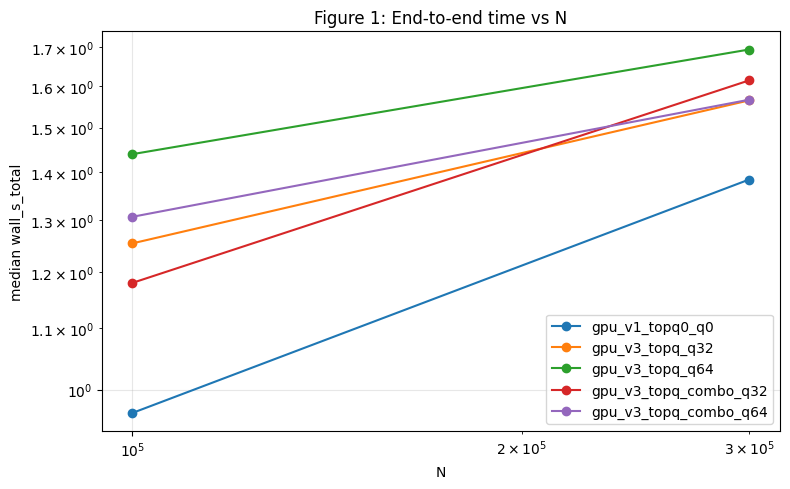

saved: outputs\weak_gpu_complexity_20260423_003358\plots\fig1_total_time_vs_n_loglog.png


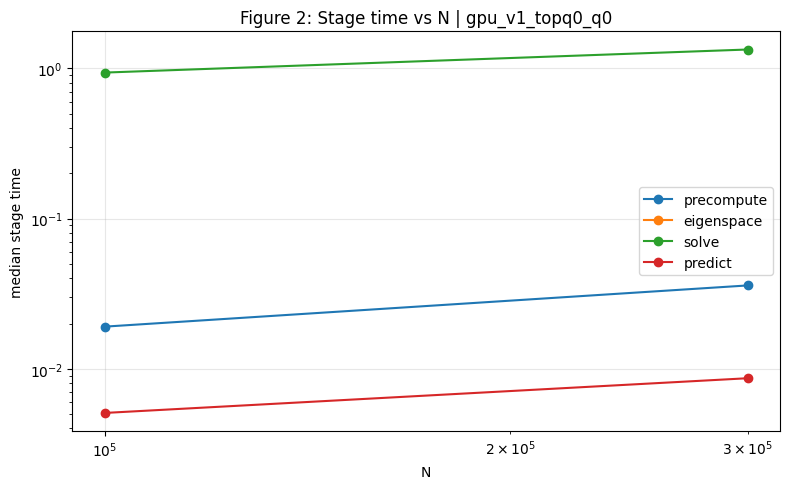

saved: outputs\weak_gpu_complexity_20260423_003358\plots\fig2_stage_vs_n_gpu_v1_topq0_q0.png


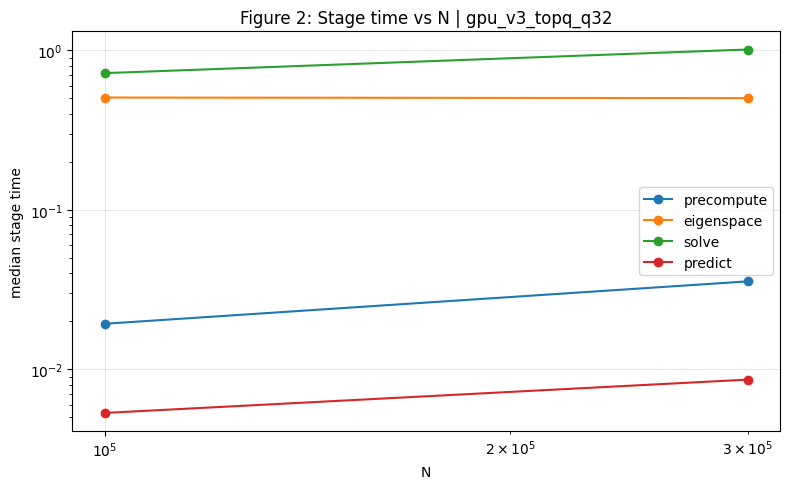

saved: outputs\weak_gpu_complexity_20260423_003358\plots\fig2_stage_vs_n_gpu_v3_topq_q32.png


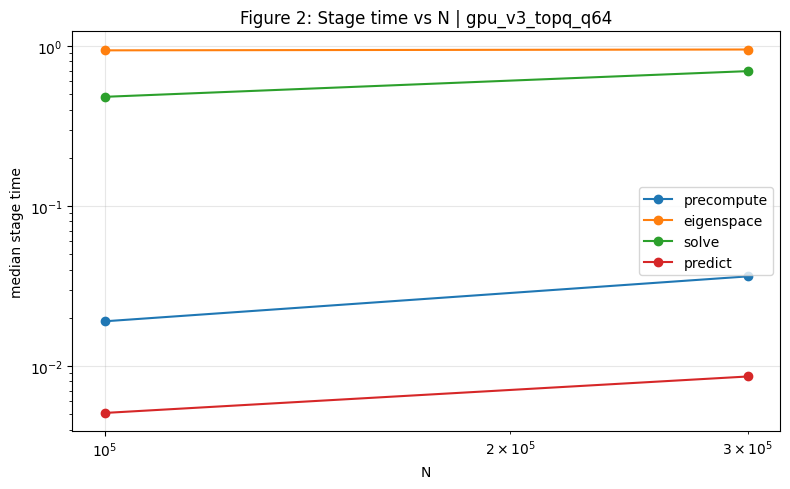

saved: outputs\weak_gpu_complexity_20260423_003358\plots\fig2_stage_vs_n_gpu_v3_topq_q64.png


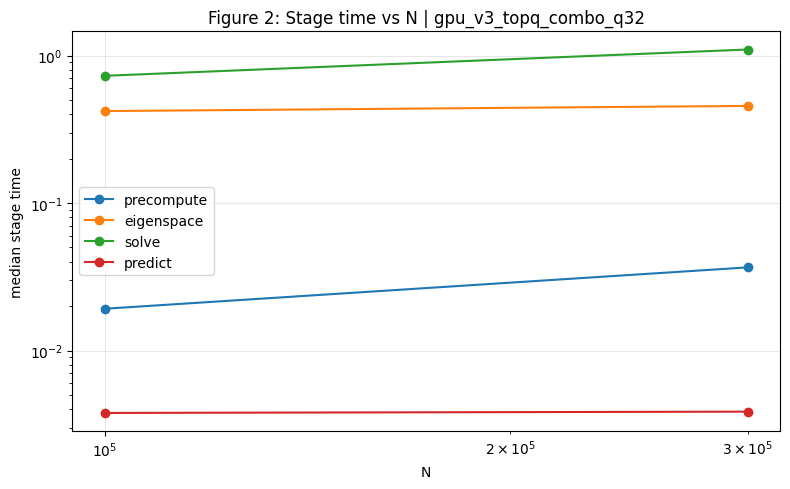

saved: outputs\weak_gpu_complexity_20260423_003358\plots\fig2_stage_vs_n_gpu_v3_topq_combo_q32.png


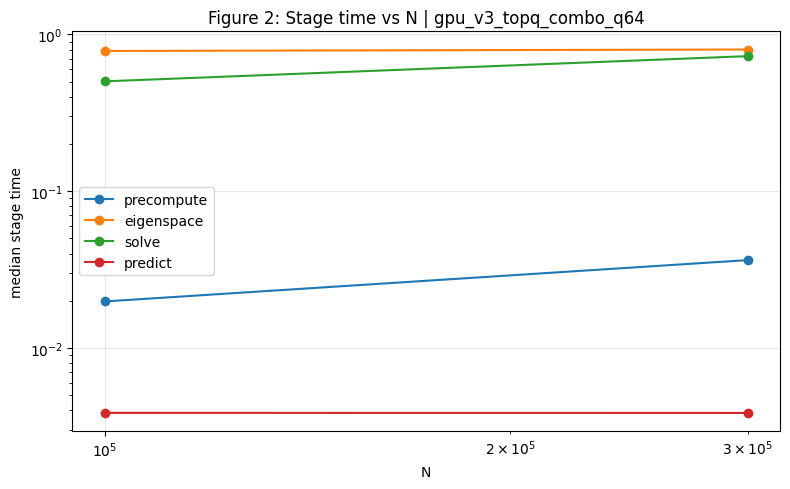

saved: outputs\weak_gpu_complexity_20260423_003358\plots\fig2_stage_vs_n_gpu_v3_topq_combo_q64.png


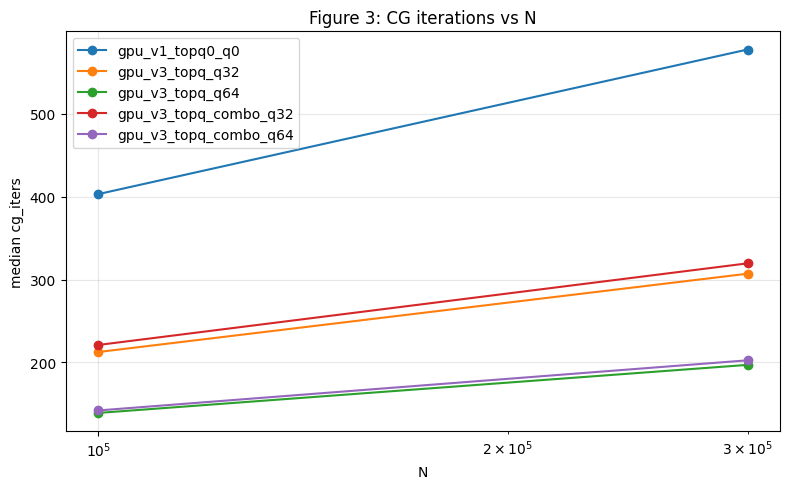

saved: outputs\weak_gpu_complexity_20260423_003358\plots\fig3_cg_iters_vs_n.png


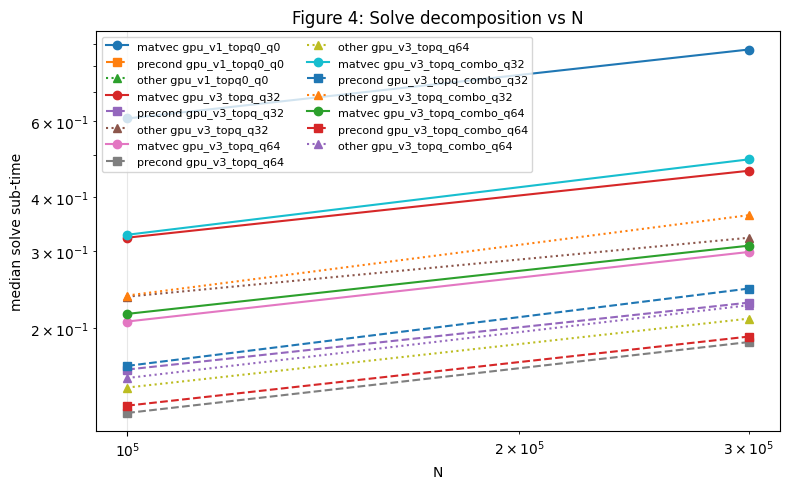

saved: outputs\weak_gpu_complexity_20260423_003358\plots\fig4_solve_decompose_vs_n.png


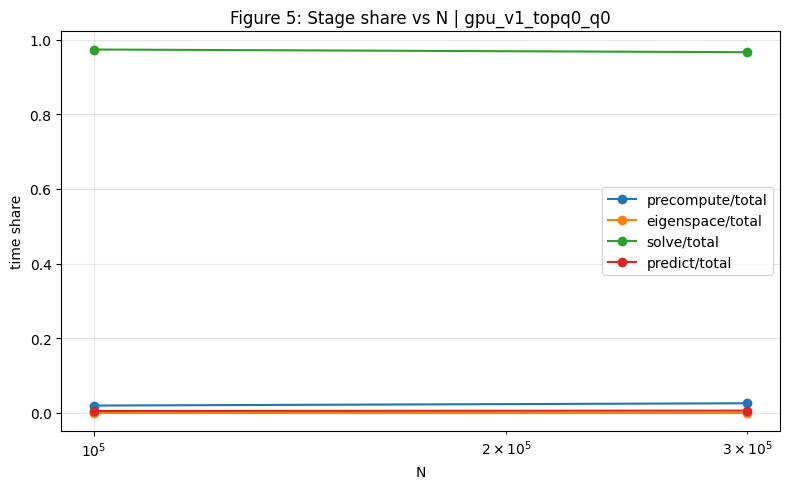

saved: outputs\weak_gpu_complexity_20260423_003358\plots\fig5_stage_share_gpu_v1_topq0_q0.png


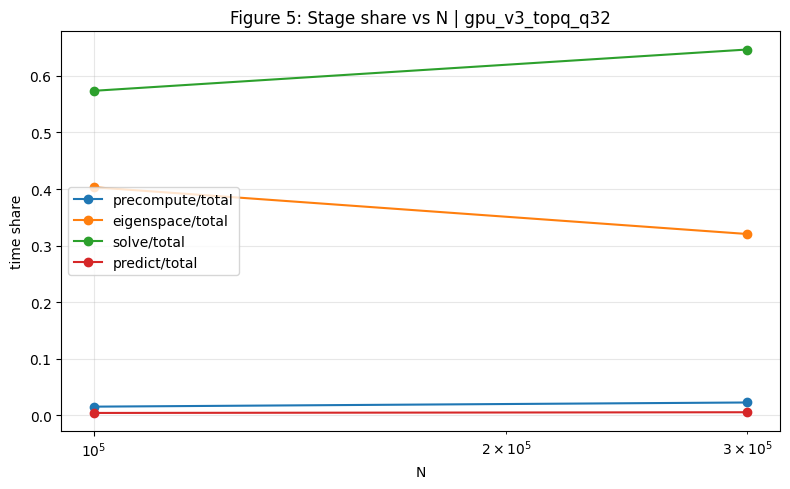

saved: outputs\weak_gpu_complexity_20260423_003358\plots\fig5_stage_share_gpu_v3_topq_q32.png


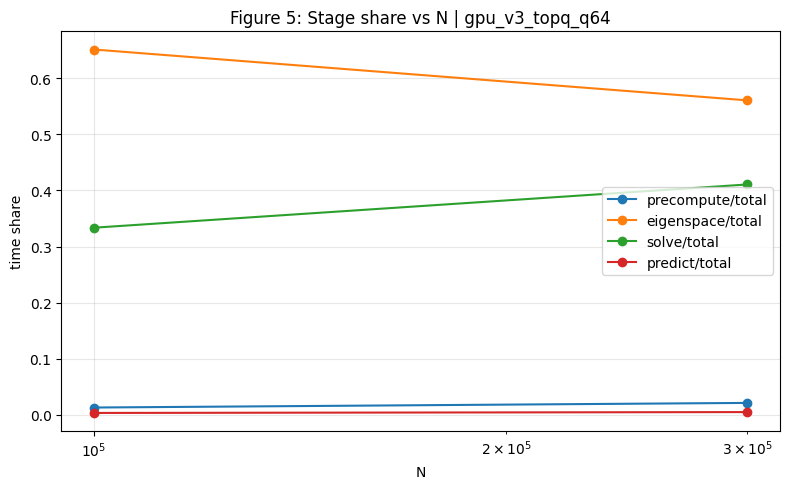

saved: outputs\weak_gpu_complexity_20260423_003358\plots\fig5_stage_share_gpu_v3_topq_q64.png


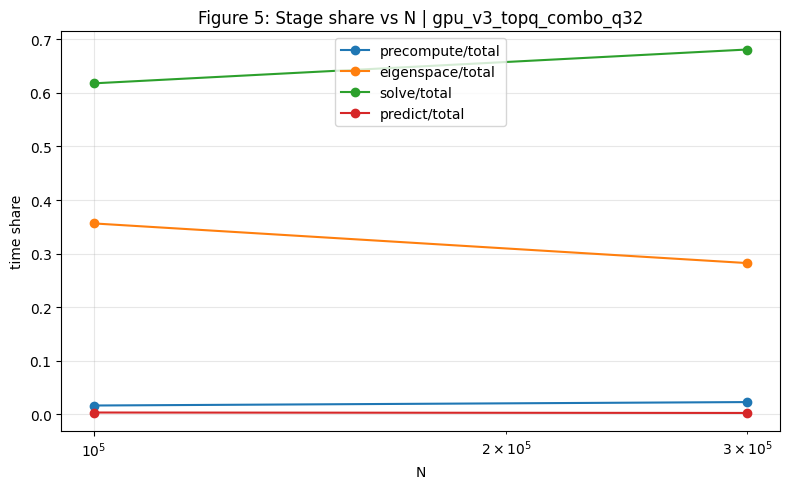

saved: outputs\weak_gpu_complexity_20260423_003358\plots\fig5_stage_share_gpu_v3_topq_combo_q32.png


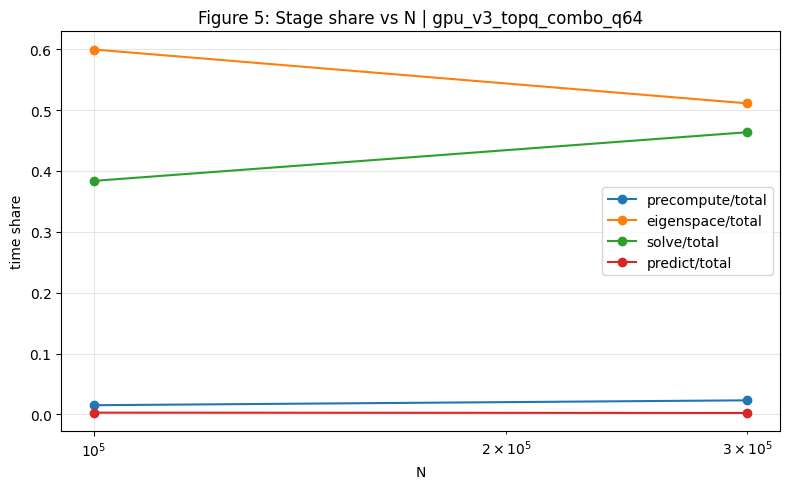

saved: outputs\weak_gpu_complexity_20260423_003358\plots\fig5_stage_share_gpu_v3_topq_combo_q64.png
all plots saved in: outputs\weak_gpu_complexity_20260423_003358\plots


In [35]:
plot_dir = OUT_DIR / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)


def _label_of(row):
    return f"{row['mode']}_q{int(row['top_q'])}"


# Figure 1: end-to-end median wall time vs N (log-log)
fig, ax = plt.subplots(figsize=(8, 5))
for (mode, top_q), g in summary_df.groupby(["mode", "top_q"]):
    g = g.sort_values("N")
    ax.plot(g["N"], g["wall_s_total_median"], marker="o", label=f"{mode}_q{int(top_q)}")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("N")
ax.set_ylabel("median wall_s_total")
ax.set_title("Figure 1: End-to-end time vs N")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig1_path = plot_dir / "fig1_total_time_vs_n_loglog.png"
fig.savefig(fig1_path, dpi=180)
plt.show()
print("saved:", fig1_path)


# Figure 2: stage time vs N by mode
for (mode, top_q), g in summary_df.groupby(["mode", "top_q"]):
    g = g.sort_values("N")
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(g["N"], g["time_precompute_median"], marker="o", label="precompute")
    ax.plot(g["N"], g["time_eigenspace_median"], marker="o", label="eigenspace")
    ax.plot(g["N"], g["time_solve_median"], marker="o", label="solve")
    ax.plot(g["N"], g["time_predict_median"], marker="o", label="predict")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("N")
    ax.set_ylabel("median stage time")
    ax.set_title(f"Figure 2: Stage time vs N | {mode}_q{int(top_q)}")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    p = plot_dir / f"fig2_stage_vs_n_{mode}_q{int(top_q)}.png"
    fig.savefig(p, dpi=180)
    plt.show()
    print("saved:", p)


# Figure 3: cg_iters vs N
fig, ax = plt.subplots(figsize=(8, 5))
for (mode, top_q), g in summary_df.groupby(["mode", "top_q"]):
    g = g.sort_values("N")
    ax.plot(g["N"], g["cg_iters_median"], marker="o", label=f"{mode}_q{int(top_q)}")
ax.set_xscale("log")
ax.set_xlabel("N")
ax.set_ylabel("median cg_iters")
ax.set_title("Figure 3: CG iterations vs N")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig3_path = plot_dir / "fig3_cg_iters_vs_n.png"
fig.savefig(fig3_path, dpi=180)
plt.show()
print("saved:", fig3_path)


# Figure 4: solve decomposition vs N
fig, ax = plt.subplots(figsize=(8, 5))
for (mode, top_q), g in summary_df.groupby(["mode", "top_q"]):
    g = g.sort_values("N")
    solve_other = g["time_solve_median"] - g["t_matvec_total_median"] - g["t_precond_total_median"]
    solve_other = solve_other.clip(lower=0)
    ax.plot(g["N"], g["t_matvec_total_median"], marker="o", linestyle="-", label=f"matvec {mode}_q{int(top_q)}")
    ax.plot(g["N"], g["t_precond_total_median"], marker="s", linestyle="--", label=f"precond {mode}_q{int(top_q)}")
    ax.plot(g["N"], solve_other, marker="^", linestyle=":", label=f"other {mode}_q{int(top_q)}")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("N")
ax.set_ylabel("median solve sub-time")
ax.set_title("Figure 4: Solve decomposition vs N")
ax.grid(True, alpha=0.3)
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
fig4_path = plot_dir / "fig4_solve_decompose_vs_n.png"
fig.savefig(fig4_path, dpi=180)
plt.show()
print("saved:", fig4_path)


# Figure 5: time share vs N (per mode)
for (mode, top_q), g in summary_df.groupby(["mode", "top_q"]):
    g = g.sort_values("N")
    total = g["wall_s_total_median"].replace(0, np.nan)
    r_pre = g["time_precompute_median"] / total
    r_eig = g["time_eigenspace_median"] / total
    r_sol = g["time_solve_median"] / total
    r_pred = g["time_predict_median"] / total

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(g["N"], r_pre, marker="o", label="precompute/total")
    ax.plot(g["N"], r_eig, marker="o", label="eigenspace/total")
    ax.plot(g["N"], r_sol, marker="o", label="solve/total")
    ax.plot(g["N"], r_pred, marker="o", label="predict/total")
    ax.set_xscale("log")
    ax.set_xlabel("N")
    ax.set_ylabel("time share")
    ax.set_title(f"Figure 5: Stage share vs N | {mode}_q{int(top_q)}")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    p = plot_dir / f"fig5_stage_share_{mode}_q{int(top_q)}.png"
    fig.savefig(p, dpi=180)
    plt.show()
    print("saved:", p)

print("all plots saved in:", plot_dir)


In [36]:
def _get_curve(df, mode, top_q):
    s = df[(df["mode"] == mode) & (df["top_q"] == top_q)].sort_values("N").copy()
    return s


v1 = _get_curve(summary_df, "gpu_v1_topq0", 0)
v3_qs = sorted([int(v) for v in summary_df.loc[summary_df["mode"] == "gpu_v3_topq", "top_q"].dropna().unique()])

print("=" * 80)
print("Q1: gpu_v1_topq0 的总时间随 N 如何增长")
if len(v1) >= 2:
    print(v1[["N", "wall_s_total_median", "local_alpha"]])
    print("Q1 observation: local_alpha 趋势见上表，可直接读 log-log 局部斜率。")
else:
    print("Q1 data insufficient")

print("=" * 80)
print("Q2: gpu_v3_topq 相对 gpu_v1_topq0 的快慢和拐点")
for q in v3_qs:
    v3 = _get_curve(summary_df, "gpu_v3_topq", q)
    m = v1.merge(v3, on=["N", "eps"], suffixes=("_v1", "_v3"))
    if m.empty:
        continue
    m["speedup_v1_over_v3"] = m["wall_s_total_median_v1"] / m["wall_s_total_median_v3"]
    m["v3_faster"] = m["speedup_v1_over_v3"] > 1.0
    print(f"top_q={q}")
    print(m[["N", "wall_s_total_median_v1", "wall_s_total_median_v3", "speedup_v1_over_v3", "v3_faster"]])

print("=" * 80)
print("Q3: 时间增长主要来自哪一段")
for (mode, top_q), g in summary_df.groupby(["mode", "top_q"]):
    g = g.sort_values("N").copy()
    for c in ["time_precompute_median", "time_eigenspace_median", "time_solve_median", "time_predict_median"]:
        g[f"ratio_{c}"] = g[c] / g["wall_s_total_median"].replace(0, np.nan)
    print(f"mode={mode}, top_q={int(top_q)}")
    print(g[["N", "ratio_time_precompute_median", "ratio_time_eigenspace_median", "ratio_time_solve_median", "ratio_time_predict_median"]])

print("=" * 80)
print("Q4: top_q>0 优势扩大还是缩小")
for q in v3_qs:
    v3 = _get_curve(summary_df, "gpu_v3_topq", q)
    m = v1.merge(v3, on=["N", "eps"], suffixes=("_v1", "_v3"))
    if m.empty:
        continue
    m["speedup_v1_over_v3"] = m["wall_s_total_median_v1"] / m["wall_s_total_median_v3"]
    print(f"top_q={q}, speedup trend")
    print(m[["N", "speedup_v1_over_v3"]])

print("=" * 80)
print("Artifacts")
print("raw csv:", RAW_CSV)
print("summary csv:", SUMMARY_CSV)
print("plots dir:", plot_dir)
print("env info:", ENV_JSON)


Q1: gpu_v1_topq0 的总时间随 N 如何增长
        N  wall_s_total_median  local_alpha
0  100000             0.964531          NaN
1  300000             1.384283     0.328865
Q1 observation: local_alpha 趋势见上表，可直接读 log-log 局部斜率。
Q2: gpu_v3_topq 相对 gpu_v1_topq0 的快慢和拐点
top_q=32
        N  wall_s_total_median_v1  wall_s_total_median_v3  speedup_v1_over_v3  \
0  100000                0.964531                1.254050            0.769133   
1  300000                1.384283                1.564688            0.884702   

   v3_faster  
0      False  
1      False  
top_q=64
        N  wall_s_total_median_v1  wall_s_total_median_v3  speedup_v1_over_v3  \
0  100000                0.964531                1.439723            0.669942   
1  300000                1.384283                1.692862            0.817718   

   v3_faster  
0      False  
1      False  
Q3: 时间增长主要来自哪一段
mode=gpu_v1_topq0, top_q=0
        N  ratio_time_precompute_median  ratio_time_eigenspace_median  \
0  100000                      0.0

如果你在本地仓库直接运行（例如 `D:/NU/ML`），可以跳过 `## For github import` 单元，直接从导入单元开始执行。

In [37]:
# ---- Selective SLQ spectral diagnostics on cross-selected (mode_spec, N) ----
import re
from dataclasses import asdict, is_dataclass

from efgp_eigenpro_py.gpu.backends import build_gpu_backend_bundle
from efgp_eigenpro_py.gpu.contexts import GPUOperatorContext, ensure_gpu_data_context
from efgp_eigenpro_py.gpu.v1_ops import apply_A_v1, gpu_precompute_v1
import importlib
import efgp_eigenpro_py.gpu.slq_diagnostics as slq_diag

slq_diag = importlib.reload(slq_diag)
SLQLanczosConfig = slq_diag.SLQLanczosConfig
run_slq_lanczos_diagnostic = slq_diag.run_slq_lanczos_diagnostic
summarize_slq_diagnostics = slq_diag.summarize_slq_diagnostics
save_slq_plots = slq_diag.save_slq_plots

# 1) Select experiment types (leave empty to use all MODE_SPECS)
SLQ_SELECTED_MODE_SPECS = [
    {"mode": "gpu_v1_topq0", "top_q": 0},
    {"mode": "gpu_v3_topq", "top_q": 64},
    {"mode": "gpu_v3_topq_combo", "top_q": 64, "combo_cfg": COMBO_CFG_V1},
]

# 2) Select N values (leave empty to use all N_LIST)
SLQ_SELECTED_N_LIST = [100_000, 300_000]

# 3) SLQ controls
SLQ_CFG = SLQLanczosConfig(
    nv=32,
    k_max=300,
    hermitian_type="complex",
    seed=0,
    breakdown_abs_tol=1e-14,
    breakdown_rel_tol=1e-12,
    reorth_mode="none",
    reorth_window=8,
    reorth_passes=2,
    sync_timing=True,
)
SLQ_SUMMARY_MODE = "spd"  # "spd" or "hermitian"
SLQ_PREFIX_STEPS = list(range(20, SLQ_CFG.k_max + 1, 20))
SLQ_SEED_BASE = 99173

SLQ_DIR = OUT_DIR / "slq_diagnostics"
SLQ_DIR.mkdir(parents=True, exist_ok=True)


def _sanitize_tag(s: str) -> str:
    return re.sub(r"[^0-9a-zA-Z_\-]+", "_", str(s)).strip("_")


def _spec_key(spec: dict) -> tuple[str, int, str]:
    mode = str(spec.get("mode", ""))
    top_q = int(spec.get("top_q", -1))
    combo_cfg = spec.get("combo_cfg", None)
    combo_name = ""
    if isinstance(combo_cfg, dict):
        combo_name = str(combo_cfg.get("name", ""))
    return (mode, top_q, combo_name)


def _to_jsonable(obj):
    if is_dataclass(obj):
        return _to_jsonable(asdict(obj))
    if isinstance(obj, dict):
        return {str(k): _to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_to_jsonable(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.floating, np.integer)):
        return obj.item()
    return obj


def _pick_mode_specs(all_specs: list[dict], selected_specs: list[dict]) -> list[dict]:
    if len(selected_specs) == 0:
        return list(all_specs)
    selected_keys = {_spec_key(s) for s in selected_specs}
    out = [s for s in all_specs if _spec_key(s) in selected_keys]
    return out


def _pick_n_list(all_n: list[int], selected_n: list[int]) -> list[int]:
    if len(selected_n) == 0:
        return [int(v) for v in all_n]
    selected_set = {int(v) for v in selected_n}
    return [int(v) for v in all_n if int(v) in selected_set]


def _q_lookup(q_map: dict, q: float) -> float:
    if not isinstance(q_map, dict):
        return float("nan")
    if q in q_map:
        return float(q_map[q])
    key = str(q)
    if key in q_map:
        return float(q_map[key])
    for k, v in q_map.items():
        try:
            if abs(float(k) - float(q)) < 1e-15:
                return float(v)
        except Exception:
            pass
    return float("nan")


def _normalize_summary_schema(summary: dict) -> tuple[dict, dict, dict]:
    """
    Support both old schema {config, run_diagnostics, prefix, final}
    and new schema {raw, derived, views}.
    """
    if isinstance(summary, dict) and all(k in summary for k in ("raw", "derived", "views")):
        return summary.get("raw", {}), summary.get("derived", {}), summary.get("views", {})

    if not isinstance(summary, dict):
        return {}, {}, {}

    final = summary.get("final", {}) if isinstance(summary.get("final", {}), dict) else {}
    prefix = summary.get("prefix", []) if isinstance(summary.get("prefix", []), list) else []
    q_map = final.get("quantiles", {}) if isinstance(final.get("quantiles", {}), dict) else {}

    raw_part = {
        "config": summary.get("config", {}),
        "run_diagnostics": summary.get("run_diagnostics", {}),
        "x_grid": np.asarray(final.get("grid", {}).get("x", []), dtype=float),
        "cdf": np.asarray(final.get("grid", {}).get("cdf", []), dtype=float),
        "density": final.get("grid", {}).get("density", {}),
        "extremal_ritz_cloud": final.get("extremal_ritz_cloud", {}),
    }

    q01 = _q_lookup(q_map, 0.01)
    q05 = _q_lookup(q_map, 0.05)
    q95 = _q_lookup(q_map, 0.95)
    q99 = _q_lookup(q_map, 0.99)
    q999 = _q_lookup(q_map, 0.999)
    bw_ratio = float((q95 - q05) / max(abs(_q_lookup(q_map, 0.5)), 1e-30)) if np.isfinite(q95) and np.isfinite(q05) else float("nan")
    tail_ratio = float((q999 - q99) / max(q99 - q01, 1e-30)) if np.isfinite(q999) and np.isfinite(q99) and np.isfinite(q01) else float("nan")
    spike_ratio = float(final.get("lambda_hat_max", np.nan) / max(q999, 1e-30)) if np.isfinite(q999) else float("nan")

    derived_part = {
        "prefix": prefix,
        "final_quantiles": q_map,
        "lambda_hat_min": float(final.get("lambda_hat_min", np.nan)),
        "lambda_hat_max": float(final.get("lambda_hat_max", np.nan)),
        "final_kappa_eff": final.get("kappa_eff", {}),
        "final_spread_eff": final.get("spread_eff", {}),
        "final_near_zero_mass": final.get("near_zero_mass", {}),
        "final_tail_ratios": {
            "bulk_width_ratio": bw_ratio,
            "tail_ratio": tail_ratio,
            "spike_ratio": spike_ratio,
        },
    }

    views_part = {
        "headline": {
            "health": "legacy",
            "dominant_issue": "",
        }
    }
    return raw_part, derived_part, views_part


def _save_slq_plots(case_dir: Path, raw_part: dict, derived_part: dict):
    plot_dir = case_dir / "plots"
    plot_dir.mkdir(parents=True, exist_ok=True)

    # Prefer module-level plotting so logic is centralized in slq_diagnostics.py
    _summary_pack = {
        "raw": raw_part if isinstance(raw_part, dict) else {},
        "derived": derived_part if isinstance(derived_part, dict) else {},
        "views": {},
    }
    try:
        save_slq_plots(_summary_pack, str(plot_dir), dpi=160)
        return
    except Exception as _plot_exc:
        print(f"warning: module-level save_slq_plots failed, fallback to notebook plotting. err={_plot_exc}")

    x = np.asarray(raw_part.get("x_grid", []), dtype=float)
    cdf = np.asarray(raw_part.get("cdf", []), dtype=float)
    density = raw_part.get("density", {}) if isinstance(raw_part, dict) else {}

    prefix = derived_part.get("prefix", []) if isinstance(derived_part, dict) else []
    q_map = derived_part.get("final_quantiles", {}) if isinstance(derived_part, dict) else {}
    cloud = raw_part.get("extremal_ritz_cloud", {}) if isinstance(raw_part, dict) else {}
    top_cloud = np.asarray(cloud.get("top", []), dtype=float)
    bottom_cloud = np.asarray(cloud.get("bottom", []), dtype=float)

    m_vals = np.asarray([int(r.get("m", 0)) for r in prefix], dtype=float)
    q001 = np.asarray([_q_lookup(r.get("quantiles", {}), 0.001) for r in prefix], dtype=float)
    q095 = np.asarray([_q_lookup(r.get("quantiles", {}), 0.95) for r in prefix], dtype=float)
    q099 = np.asarray([_q_lookup(r.get("quantiles", {}), 0.99) for r in prefix], dtype=float)
    kappa01 = np.asarray([_q_lookup(r.get("kappa_eff", {}), 0.01) for r in prefix], dtype=float)
    kappa05 = np.asarray([_q_lookup(r.get("kappa_eff", {}), 0.05) for r in prefix], dtype=float)

    # For legacy compatibility: density keys can be float or string.
    dens_002 = np.asarray(density.get(0.002, density.get("0.002", [])), dtype=float)
    dens_005 = np.asarray(density.get(0.005, density.get("0.005", [])), dtype=float)
    dens_010 = np.asarray(density.get(0.01, density.get("0.01", [])), dtype=float)

    lam_min = float(derived_part.get("lambda_hat_min", np.nan)) if isinstance(derived_part, dict) else float("nan")

    # Optional: rebuild left-edge density on local grid from final prefix atoms.
    atoms_zoom_nodes = np.asarray([], dtype=float)
    atoms_zoom_weights = np.asarray([], dtype=float)
    prefix_atoms = raw_part.get("prefix_atoms", []) if isinstance(raw_part, dict) else []
    if isinstance(prefix_atoms, list) and len(prefix_atoms) > 0:
        max_entry = None
        max_m = -1
        for item in prefix_atoms:
            try:
                mm = int(item.get("m", -1))
            except Exception:
                mm = -1
            if mm > max_m:
                max_m = mm
                max_entry = item
        if isinstance(max_entry, dict):
            atoms_zoom_nodes = np.asarray(max_entry.get("nodes", []), dtype=float)
            atoms_zoom_weights = np.asarray(max_entry.get("weights", []), dtype=float)

    # 1) Global CDF (linear)
    if x.size > 0 and cdf.size == x.size:
        fig, ax = plt.subplots(figsize=(6.4, 4.2))
        ax.plot(x, cdf)
        ax.set_title("Global spectral CDF")
        ax.set_xlabel("eigenvalue")
        ax.set_ylabel("CDF")
        ax.set_ylim(-0.02, 1.02)
        fig.tight_layout()
        fig.savefig(plot_dir / "fig1_global_cdf.png", dpi=160)
        plt.close(fig)

        # 1b) symlog-x view to avoid left-edge compression
        fig, ax = plt.subplots(figsize=(6.4, 4.2))
        ax.plot(x, cdf)
        ax.set_xscale("symlog", linthresh=1.0)
        ax.set_title("Global spectral CDF (symlog-x)")
        ax.set_xlabel("eigenvalue")
        ax.set_ylabel("CDF")
        ax.set_ylim(-0.02, 1.02)
        fig.tight_layout()
        fig.savefig(plot_dir / "fig1b_global_cdf_symlogx.png", dpi=160)
        plt.close(fig)

    # 2) Left-edge density zoom: prefer local-grid recomputation from atoms.
    left_lo = 0.0
    left_hi = 1.0
    if np.isfinite(lam_min) and lam_min > 0.0:
        left_lo = max(0.0, 0.8 * lam_min)
        left_hi = max(0.5, 4.5 * lam_min)

    x_zoom = np.linspace(left_lo, left_hi, 1000)
    dens_zoom_005 = np.asarray([], dtype=float)
    dens_zoom_010 = np.asarray([], dtype=float)

    if atoms_zoom_nodes.size > 0 and atoms_zoom_weights.size == atoms_zoom_nodes.size:
        class _Atoms:
            pass

        atoms_obj = _Atoms()
        atoms_obj.nodes = atoms_zoom_nodes
        atoms_obj.weights = atoms_zoom_weights

        if x.size > 1:
            span = float(np.max(x) - np.min(x))
        else:
            span = float(np.max(atoms_zoom_nodes) - np.min(atoms_zoom_nodes)) if atoms_zoom_nodes.size > 1 else 1.0
        span = max(span, 1e-30)

        dens_zoom_005 = evaluate_gaussian_density(atoms_obj, x_zoom, sigma=0.005 * span)
        dens_zoom_010 = evaluate_gaussian_density(atoms_obj, x_zoom, sigma=0.01 * span)
    else:
        # fallback: use precomputed global grid density but with non-empty mask window
        mask = (x >= 0.0) & (x <= 50.0)
        if dens_005.size == x.size:
            dens_zoom_005 = dens_005[mask]
        if dens_010.size == x.size:
            dens_zoom_010 = dens_010[mask]
        x_zoom = x[mask]

    if x_zoom.size > 0:
        fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.0))
        # CDF zoom
        if x.size > 0 and cdf.size == x.size:
            mask_cdf = (x >= left_lo) & (x <= left_hi)
            axes[0].plot(x[mask_cdf], cdf[mask_cdf])
        axes[0].set_title(f"CDF near left edge [{left_lo:.3g}, {left_hi:.3g}]")
        axes[0].set_xlabel("eigenvalue")
        axes[0].set_ylabel("CDF")

        # Density zoom
        if dens_zoom_005.size == x_zoom.size:
            axes[1].plot(x_zoom, dens_zoom_005, label="sigma=0.005")
        if dens_zoom_010.size == x_zoom.size:
            axes[1].plot(x_zoom, dens_zoom_010, label="sigma=0.01")
        if np.isfinite(lam_min):
            axes[1].axvline(lam_min, linestyle="--", alpha=0.6, label="lambda_min")
        axes[1].set_title("Density near left edge (local grid)")
        axes[1].set_xlabel("eigenvalue")
        axes[1].set_ylabel("density")
        axes[1].legend(loc="best")

        fig.tight_layout()
        fig.savefig(plot_dir / "fig2_left_edge_zoom.png", dpi=160)
        plt.close(fig)

    # 3a) Prefix bulk quantiles (q0.001, q0.95)
    if m_vals.size > 0:
        fig, ax = plt.subplots(figsize=(6.4, 4.2))
        ax.plot(m_vals, q001, label="q0.001")
        ax.plot(m_vals, q095, label="q0.95")
        ax.set_title("Prefix bulk quantiles vs m")
        ax.set_xlabel("Lanczos steps m")
        ax.set_ylabel("value")
        ax.legend(loc="best")
        fig.tight_layout()
        fig.savefig(plot_dir / "fig3a_prefix_bulk_quantiles.png", dpi=160)
        plt.close(fig)

        # 3b) Prefix upper-tail quantile (q0.99)
        fig, ax = plt.subplots(figsize=(6.4, 4.2))
        ax.plot(m_vals, q099, label="q0.99")
        ax.set_title("Prefix upper-tail quantile vs m")
        ax.set_xlabel("Lanczos steps m")
        ax.set_ylabel("value")
        ax.legend(loc="best")
        fig.tight_layout()
        fig.savefig(plot_dir / "fig3b_prefix_upper_tail_q99.png", dpi=160)
        plt.close(fig)

        # 3c) Effective condition surrogates
        fig, ax = plt.subplots(figsize=(6.4, 4.2))
        if np.any(np.isfinite(kappa01)):
            ax.plot(m_vals, kappa01, label="kappa_eff(0.01)")
        if np.any(np.isfinite(kappa05)):
            ax.plot(m_vals, kappa05, label="kappa_eff(0.05)")
        ax.set_yscale("log")
        ax.set_title("Effective condition surrogates vs m")
        ax.set_xlabel("Lanczos steps m")
        ax.set_ylabel("value (log)")
        ax.legend(loc="best")
        fig.tight_layout()
        fig.savefig(plot_dir / "fig3c_prefix_kappa_eff.png", dpi=160)
        plt.close(fig)

    # 4a) Bottom Ritz cloud
    if bottom_cloud.size > 0:
        fig, ax = plt.subplots(figsize=(6.4, 4.2))
        ax.scatter(np.arange(bottom_cloud.size), bottom_cloud, s=10)
        ax.set_title("Bottom Ritz cloud")
        ax.set_xlabel("index")
        ax.set_ylabel("Ritz value")
        fig.tight_layout()
        fig.savefig(plot_dir / "fig4a_bottom_ritz_cloud.png", dpi=160)
        plt.close(fig)

    # 4b) Top Ritz cloud
    if top_cloud.size > 0:
        fig, ax = plt.subplots(figsize=(6.4, 4.2))
        ax.scatter(np.arange(top_cloud.size), top_cloud, s=10)
        ax.set_title("Top Ritz cloud")
        ax.set_xlabel("index")
        ax.set_ylabel("Ritz value")
        fig.tight_layout()
        fig.savefig(plot_dir / "fig4b_top_ritz_cloud.png", dpi=160)
        plt.close(fig)

    # Optional: refreshed 2x2 dashboard
    if x.size > 0 and cdf.size == x.size and m_vals.size > 0:
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))

        axes[0, 0].plot(x, cdf)
        axes[0, 0].set_xscale("symlog", linthresh=1.0)
        axes[0, 0].set_title("Global CDF (symlog-x)")
        axes[0, 0].set_xlabel("eigenvalue")
        axes[0, 0].set_ylabel("CDF")

        if x_zoom.size > 0 and dens_zoom_005.size == x_zoom.size:
            axes[0, 1].plot(x_zoom, dens_zoom_005, label="sigma=0.005")
        if x_zoom.size > 0 and dens_zoom_010.size == x_zoom.size:
            axes[0, 1].plot(x_zoom, dens_zoom_010, label="sigma=0.01")
        if np.isfinite(lam_min):
            axes[0, 1].axvline(lam_min, linestyle="--", alpha=0.6, label="lambda_min")
        axes[0, 1].set_title("Left-edge density (local grid)")
        axes[0, 1].set_xlabel("eigenvalue")
        axes[0, 1].set_ylabel("density")
        axes[0, 1].legend(loc="best")

        axes[1, 0].plot(m_vals, q001, label="q0.001")
        axes[1, 0].plot(m_vals, q095, label="q0.95")
        axes[1, 0].set_title("Prefix bulk quantiles")
        axes[1, 0].set_xlabel("m")
        axes[1, 0].set_ylabel("value")
        axes[1, 0].legend(loc="best")

        if top_cloud.size > 0:
            axes[1, 1].scatter(np.arange(top_cloud.size), top_cloud, s=10, label="top")
        if bottom_cloud.size > 0:
            axes[1, 1].scatter(np.arange(bottom_cloud.size), bottom_cloud, s=10, label="bottom")
        axes[1, 1].set_title("Extremal Ritz cloud")
        axes[1, 1].set_xlabel("index")
        axes[1, 1].set_ylabel("Ritz value")
        axes[1, 1].legend(loc="best")

        fig.tight_layout()
        fig.savefig(plot_dir / "dashboard_2x2.png", dpi=160)
        plt.close(fig)


def _build_slq_matvec_and_size(x_train: np.ndarray, y_train: np.ndarray):
    solver = EFGPSolver(
        kernel=kernel,
        reg_lambda=REG_LAMBDA,
        eps=EPS,
        nufft_tol=1e-10,
        l2scaled=L2_SCALED,
    )
    cfg = GPURunConfig(
        reg_lambda=REG_LAMBDA,
        tol=SOLVE_TOL,
        maxiter=GPU_MAXITER,
        chunk_size=None,
        debug_finite_checks=False,
        backend=BackendConfig(nufft=GPU_NUFFT),
    )

    backend = build_gpu_backend_bundle(cfg.backend)
    data_ctx = ensure_gpu_data_context(backend, x_train, y_train, state=None)
    data_ctx.meta["debug_finite_checks"] = bool(cfg.debug_finite_checks)
    op_ctx = GPUOperatorContext()
    data_ctx = gpu_precompute_v1(
        backend,
        solver.kernel,
        solver.eps,
        solver.nufft_tol,
        data_ctx,
        op_ctx,
        l2scaled=solver.l2scaled,
        chunk_size=cfg.chunk_size,
    )

    sigma2 = float(cfg.reg_lambda)

    def _matvec(v, out):
        apply_A_v1(backend, data_ctx, v, sigma2, op_ctx, out=out)

    size = int(data_ctx.rhs_gpu.size)
    return backend, _matvec, size


picked_specs = _pick_mode_specs(MODE_SPECS, SLQ_SELECTED_MODE_SPECS)
picked_n = _pick_n_list(N_LIST, SLQ_SELECTED_N_LIST)

print("SLQ selected mode specs:")
for s in picked_specs:
    print("  ", s)
print("SLQ selected N list:", picked_n)

if len(picked_specs) == 0:
    raise ValueError("No mode spec selected for SLQ. Check SLQ_SELECTED_MODE_SPECS.")
if len(picked_n) == 0:
    raise ValueError("No N selected for SLQ. Check SLQ_SELECTED_N_LIST.")

slq_rows = []
case_idx = 0
for n_train in picked_n:
    for spec in picked_specs:
        case_idx += 1
        mode = str(spec.get("mode", ""))
        top_q = int(spec.get("top_q", 0))
        combo_name = ""
        if isinstance(spec.get("combo_cfg", None), dict):
            combo_name = str(spec["combo_cfg"].get("name", ""))

        case_seed = int(SLQ_SEED_BASE + case_idx)
        print("=" * 100)
        print(f"[SLQ] start N={n_train}, mode={mode}, top_q={top_q}, combo={combo_name}, seed={case_seed}")

        x_train, y_train = make_dataset(DIM, int(n_train), true_func_2d, noise=NOISE, seed=case_seed)
        backend, matvec, size = _build_slq_matvec_and_size(x_train, y_train)

        t0 = time.perf_counter()
        slq_res = run_slq_lanczos_diagnostic(
            backend=backend,
            matvec=matvec,
            size=size,
            cfg=SLQ_CFG,
        )
        summary = summarize_slq_diagnostics(
            slq_res,
            prefix_steps=SLQ_PREFIX_STEPS,
            spectrum_mode=SLQ_SUMMARY_MODE,
        )
        t1 = time.perf_counter()

        raw_part, derived_part, views_part = _normalize_summary_schema(summary)

        lam_min = float(derived_part.get("lambda_hat_min", np.nan))
        lam_max = float(derived_part.get("lambda_hat_max", np.nan))
        q_map = derived_part.get("final_quantiles", {}) if isinstance(derived_part, dict) else {}
        q01 = _q_lookup(q_map, 0.01)
        q99 = _q_lookup(q_map, 0.99)

        mode_tag = _sanitize_tag(mode)
        combo_tag = _sanitize_tag(combo_name) if combo_name else "none"
        case_tag = f"N{int(n_train)}_{mode_tag}_q{int(top_q)}_combo_{combo_tag}_seed{case_seed}"
        case_dir = SLQ_DIR / case_tag
        case_dir.mkdir(parents=True, exist_ok=True)

        np.savez_compressed(
            case_dir / "lanczos_coeffs.npz",
            alpha=slq_res.alpha,
            beta=slq_res.beta,
            active_steps=slq_res.active_steps,
        )

        (case_dir / "slq_summary.json").write_text(
            json.dumps(_to_jsonable(summary), indent=2),
            encoding="utf-8",
        )

        x_grid = np.asarray(raw_part.get("x_grid", []), dtype=float)
        cdf_grid = np.asarray(raw_part.get("cdf", []), dtype=float)
        density_dict = raw_part.get("density", {}) if isinstance(raw_part, dict) else {}
        grid_df = pd.DataFrame({"x": x_grid, "cdf": cdf_grid})
        if isinstance(density_dict, dict):
            for fac, den in density_dict.items():
                col = f"density_sigmafac_{fac}"
                grid_df[col] = np.asarray(den, dtype=float)
        grid_df.to_csv(case_dir / "slq_grid.csv", index=False)

        _save_slq_plots(case_dir, raw_part, derived_part)

        row = {
            "case_tag": case_tag,
            "N": int(n_train),
            "mode": mode,
            "top_q": int(top_q),
            "combo_name": combo_name,
            "seed": int(case_seed),
            "size": int(size),
            "wall_s": float(t1 - t0),
            "lambda_hat_min": lam_min,
            "lambda_hat_max": lam_max,
            "q01": q01,
            "q99": q99,
            "m_final": int(derived_part.get("prefix", [])[-1].get("m", SLQ_CFG.k_max)) if (isinstance(derived_part, dict) and len(derived_part.get("prefix", [])) > 0) else int(SLQ_CFG.k_max),
            "health": str(views_part.get("headline", {}).get("health", "")) if isinstance(views_part, dict) else "",
            "dominant_issue": str(views_part.get("headline", {}).get("dominant_issue", "")) if isinstance(views_part, dict) else "",
            "out_dir": str(case_dir),
        }
        slq_rows.append(row)

        print(f"[SLQ] done case={case_tag}")
        print(f"      lambda_hat_min={lam_min:.6e}, lambda_hat_max={lam_max:.6e}, q01={q01:.6e}, q99={q99:.6e}")
        print(f"      health={row['health']}, dominant_issue={row['dominant_issue']}")
        print(f"      saved: {case_dir}")
        if not (np.isfinite(lam_min) and np.isfinite(lam_max) and np.isfinite(q01) and np.isfinite(q99)):
            print("      warning: NaN detected in compact metrics, check slq_summary.json and schema normalization.")

slq_df = pd.DataFrame(slq_rows)
slq_csv = SLQ_DIR / "slq_cases_summary.csv"
slq_df.to_csv(slq_csv, index=False)
print("=" * 100)
print("SLQ cross-selected diagnostics finished.")
print("summary csv:", slq_csv)
print(slq_df)


SLQ selected mode specs:
   {'mode': 'gpu_v1_topq0', 'top_q': 0}
   {'mode': 'gpu_v3_topq', 'top_q': 64}
   {'mode': 'gpu_v3_topq_combo', 'top_q': 64, 'combo_cfg': {'name': 'combo_g0p1_e100_s0p3', 'kind': 'combo', 'grid_scale': 0.1, 'grid_m': None, 'eps_factor': 100.0, 'subsample_frac': 0.3, 'subsample_seed': 0, 'sur_iter': 1, 'refine_iter': 1, 'oversample': 16, 'block_size': None}}
SLQ selected N list: [100000, 300000]
[SLQ] start N=100000, mode=gpu_v1_topq0, top_q=0, combo=, seed=99174
[SLQ] done case=N100000_gpu_v1_topq0_q0_combo_none_seed99174
      lambda_hat_min=1.009829e-01, lambda_hat_max=5.551332e+03, q01=1.009829e-01, q99=6.941250e+00
      health=stable, dominant_issue=upper_spikes
      saved: outputs\weak_gpu_complexity_20260423_003358\slq_diagnostics\N100000_gpu_v1_topq0_q0_combo_none_seed99174
[SLQ] start N=100000, mode=gpu_v3_topq, top_q=64, combo=, seed=99175
[SLQ] done case=N100000_gpu_v3_topq_q64_combo_none_seed99175
      lambda_hat_min=1.009870e-01, lambda_hat_max=

In [ ]:
##for colab download
import os
from google.colab import files

# 1. 定义你想下载的文件夹路径
folder_path = 'outputs'
zip_filename = 'experiment_results_20260422.zip'

# 2. 检查路径是否存在
if os.path.exists(folder_path):
    print(f"正在打包文件夹: {folder_path} ...")
    # 使用命令行工具 zip 进行压缩，-r 表示递归压缩子目录，-q 表示静默模式
    !zip -r -q {zip_filename} {folder_path}
    
    print(f"打包完成，正在启动下载: {zip_filename}")
    files.download(zip_filename)
else:
    print(f"❌ 错误：找不到文件夹 {folder_path}")